#**MOVIE RATING PREDICTION WITH PYTHON**

# Preface

In the age of digital content, movie ratings play a crucial role in influencing viewer choices and the success of a film. This project delves into the world of movie data to uncover the factors that contribute to a movie's rating. By leveraging machine learning, we aim to build a model that can predict a movie's rating based on its attributes, providing valuable insights for filmmakers and audiences alike.

# Objective

The primary objective of this project is to develop a machine learning model that can accurately predict the IMDb rating of a movie. To achieve this, we will perform a comprehensive analysis of a dataset of Indian films, exploring the relationships between various features—such as genre, director, and actors—and the movie's rating. We will also compare the performance of different regression algorithms to identify the most effective model for this task.

# Dataset Overview

The dataset used in this project is the "IMDb Movies India" dataset, which contains information on thousands of Indian films. The key features in this dataset include:

*   **Name:** The title of the movie.
*   **Year:** The year the movie was released.
*   **Duration:** The length of the movie in minutes.
*   **Genre:** The genre(s) of the movie.
*   **Rating:** The IMDb rating of the movie (our target variable).
*   **Votes:** The number of votes the movie has received.
*   **Director:** The director of the movie.
*   **Actor 1, Actor 2, Actor 3:** The lead actors in the movie.

The dataset presents several challenges, including missing values and a large number of categorical features, which will be addressed during the data preprocessing phase.

## Tools Used

This project utilizes a suite of popular Python libraries for data science and machine learning:

*   **Pandas:** For data manipulation and analysis.
*   **NumPy:** For numerical operations.
*   **Matplotlib and Seaborn:** For data visualization.
*   **Scikit-learn:** for machine learning tasks, including data preprocessing, model training, and evaluation.
*   **Google Colab:** As the development environment, providing a convenient platform for coding and collaboration.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# IMPORT DATASET

In [6]:
!unzip /content/drive/MyDrive/movie/movie.zip -d /content/drive/MyDrive/movie/

Archive:  /content/drive/MyDrive/movie/movie.zip
  inflating: /content/drive/MyDrive/movie/IMDb Movies India.csv  


In [7]:
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/drive/MyDrive/movie/IMDb Movies India.csv', encoding='latin1')

# Display the first few rows of the dataframe
display(df.head())

,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


# Exploratory Data Analysis (EDA)

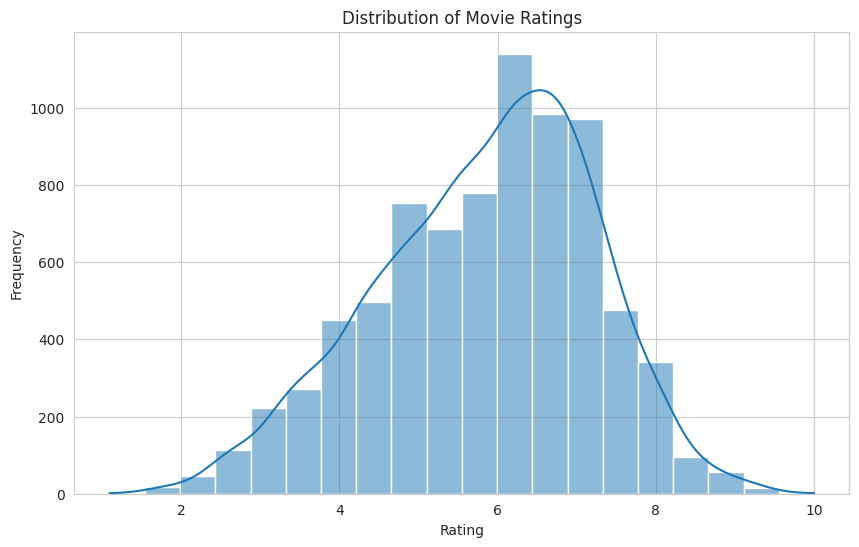

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style of the visualization
sns.set_style('whitegrid')

# Create a histogram of the 'Rating' column
plt.figure(figsize=(10, 6))
sns.histplot(df['Rating'], bins=20, kde=True)
plt.title('Distribution of Movie Ratings')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

/tmp/ipython-input-20-2066310704.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=genre_avg_ratings.values, y=genre_avg_ratings.index, palette='viridis')


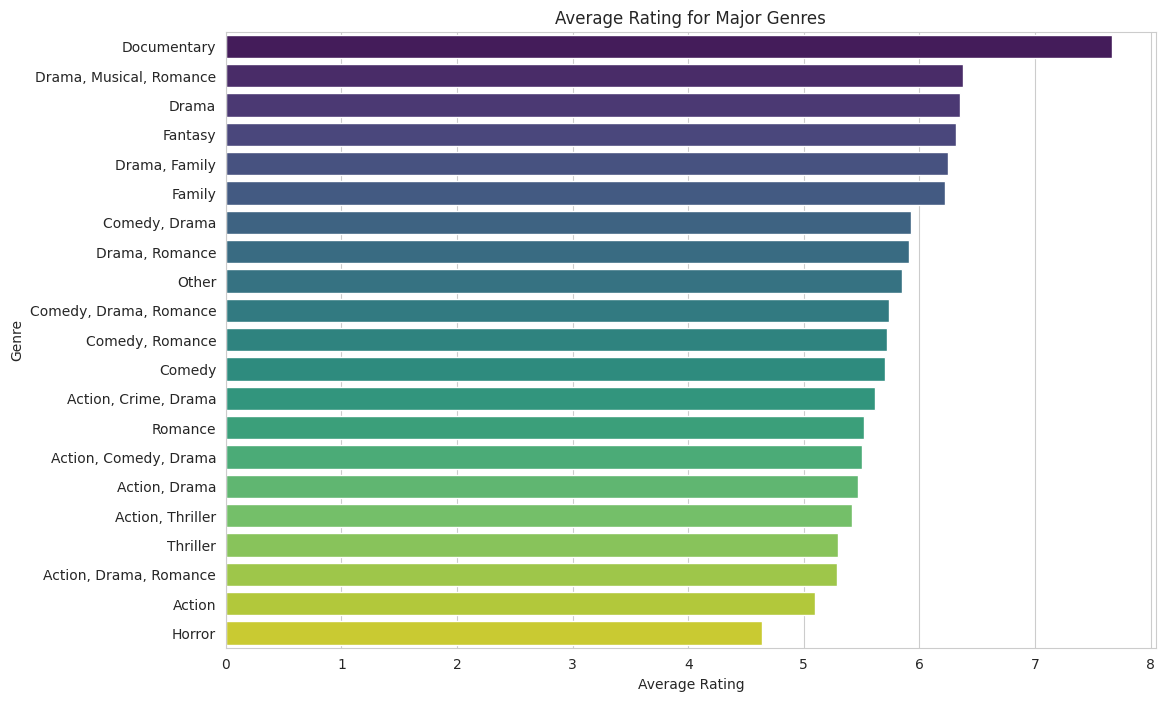

In [20]:
# Calculate the average rating for each cleaned genre
genre_avg_ratings = df.groupby('Genre_Cleaned')['Rating'].mean().sort_values(ascending=False)

# Create a bar plot
plt.figure(figsize=(12, 8))
sns.barplot(x=genre_avg_ratings.values, y=genre_avg_ratings.index, palette='viridis')
plt.title('Average Rating for Major Genres')
plt.xlabel('Average Rating')
plt.ylabel('Genre')
plt.show()

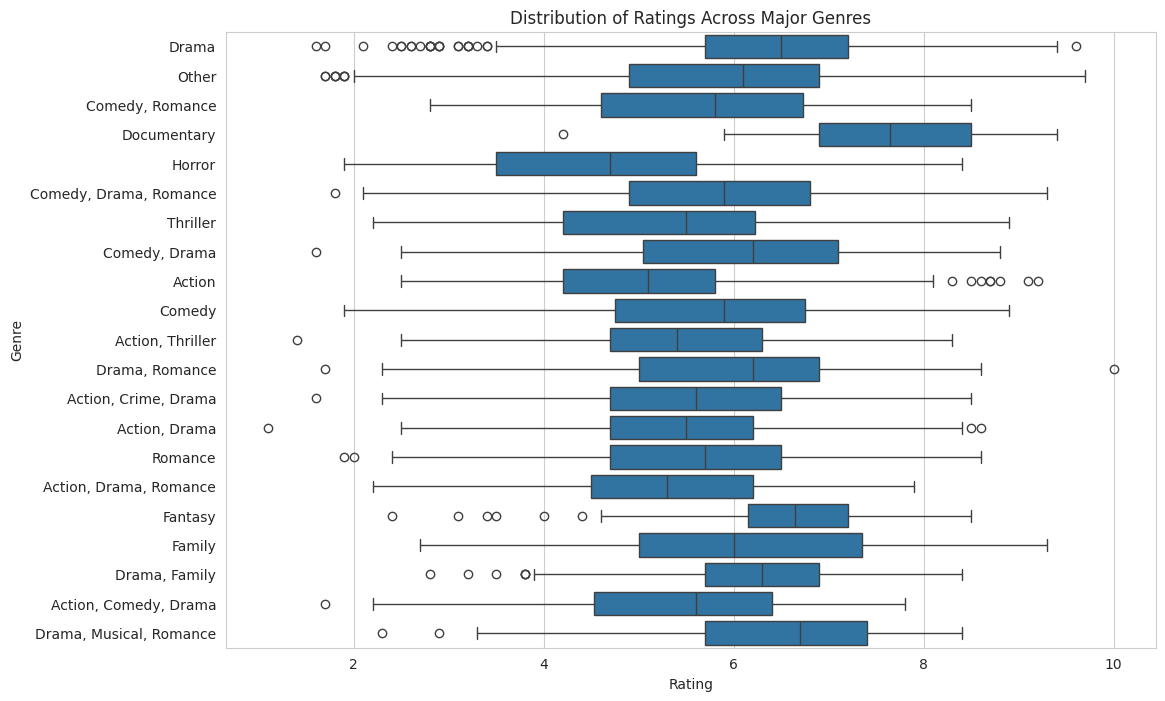

In [11]:
# Get the value counts of the 'Genre' column
genre_counts = df['Genre'].value_counts()

# Identify genres with less than a certain threshold (e.g., 100 movies)
other_genres = genre_counts[genre_counts < 100].index

# Replace these genres with 'Other'
df['Genre_Cleaned'] = df['Genre'].replace(other_genres, 'Other')

# Now let's create the box plot again with the cleaned genres
plt.figure(figsize=(12, 8))
sns.boxplot(x='Rating', y='Genre_Cleaned', data=df)
plt.title('Distribution of Ratings Across Major Genres')
plt.xlabel('Rating')
plt.ylabel('Genre')
plt.show()

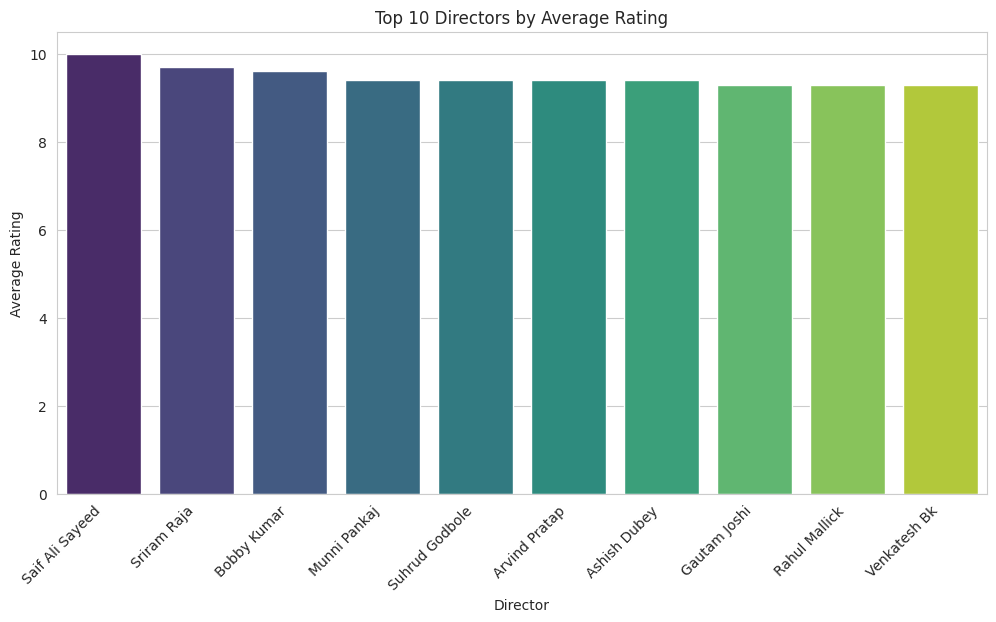

In [13]:
# Calculate the average rating for each director
director_ratings = df.groupby('Director')['Rating'].mean().sort_values(ascending=False)

# Get the top 10 directors by average rating
top_10_directors = director_ratings.head(10)

# Create a bar plot of the top 10 directors
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_directors.index, y=top_10_directors.values, hue=top_10_directors.index, palette='viridis', legend=False)
plt.title('Top 10 Directors by Average Rating')
plt.xlabel('Director')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.show()

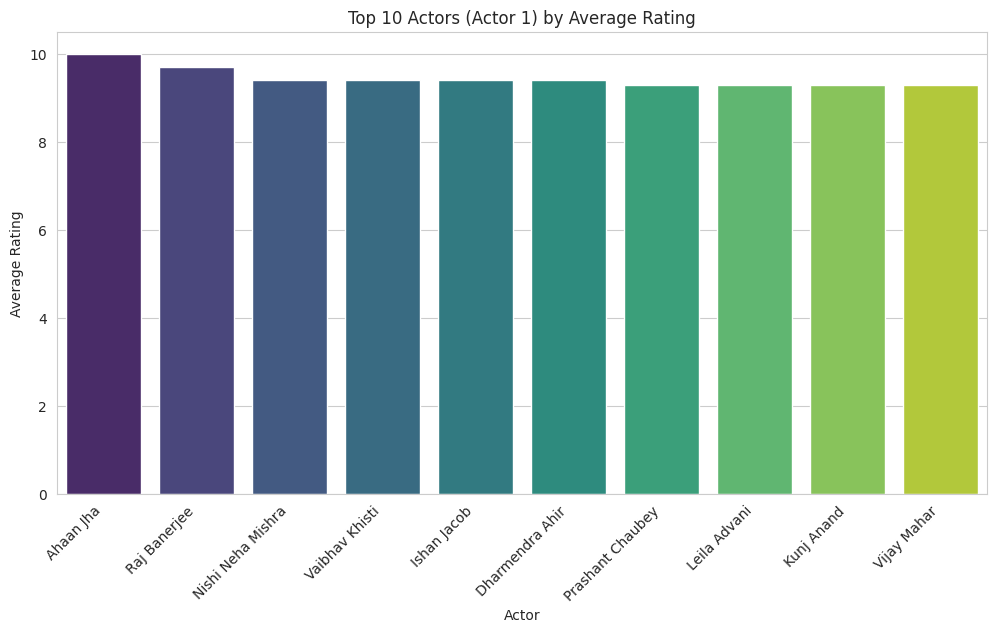

In [14]:
# Calculate the average rating for each actor in 'Actor 1'
actor1_ratings = df.groupby('Actor 1')['Rating'].mean().sort_values(ascending=False)

# Get the top 10 actors by average rating
top_10_actors = actor1_ratings.head(10)

# Create a bar plot of the top 10 actors
plt.figure(figsize=(12, 6))
sns.barplot(x=top_10_actors.index, y=top_10_actors.values, hue=top_10_actors.index, palette='viridis', legend=False)
plt.title('Top 10 Actors (Actor 1) by Average Rating')
plt.xlabel('Actor')
plt.ylabel('Average Rating')
plt.xticks(rotation=45, ha='right')
plt.show()

### Key EDA Insights

*   **Rating Distribution:** The movie ratings in this dataset tend to be clustered around the 6.0 to 7.5 range, with a roughly normal distribution. This indicates that most movies are rated as average to slightly above average.

*   **Genre and Ratings:** There is a clear relationship between genre and movie ratings.
    *   Documentaries, on average, have the highest ratings.
    *   Action and Horror movies, on the other hand, tend to have lower average ratings.

*   **Top Directors and Actors:**
    *   A small number of directors and actors are associated with exceptionally high-rated movies.
    *   The top directors and actors in this dataset are not necessarily the most famous ones, which might be due to the specific nature of the "IMDb India" dataset.

*   **Data Quality:** The dataset has a significant number of missing values, particularly in the 'Duration', 'Genre', 'Rating', and 'Votes' columns. This necessitated a data cleaning and imputation process before we could proceed with modeling.

# data preprocessing and feature engineering

In [17]:
# Create a copy of the dataframe to avoid modifying the original
df_processed = df.copy()

# Drop rows with missing ratings, as they are our target variable
df_processed.dropna(subset=['Rating'], inplace=True)

# Impute missing values in other columns
# For categorical columns, we'll fill with the mode
for col in ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']:
    mode_value = df_processed[col].mode()[0]
    df_processed[col] = df_processed[col].fillna(mode_value)

# Convert 'Year' and 'Duration' to numeric, coercing errors
df_processed['Year'] = pd.to_numeric(df_processed['Year'].str.replace(r'[()]', '', regex=True), errors='coerce')
df_processed['Duration'] = pd.to_numeric(df_processed['Duration'].str.replace(' min', ''), errors='coerce')

# For 'Year' and 'Duration', we'll fill with the median
for col in ['Year', 'Duration']:
    median_value = df_processed[col].median()
    df_processed[col] = df_processed[col].fillna(median_value)


# One-hot encode categorical features
df_processed = pd.get_dummies(df_processed, columns=['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3'], drop_first=True)

# Display the first few rows of the processed dataframe
display(df_processed.head())

,Name,Year,Duration,Rating,Votes,Genre_Cleaned,"Genre_Action, Adventure","Genre_Action, Adventure, Biography","Genre_Action, Adventure, Comedy","Genre_Action, Adventure, Crime",...,Actor 3_Zarine Ali,Actor 3_Zayed Khan,Actor 3_Zebunissa,Actor 3_Zeenat Aman,Actor 3_Zeeshan Khan,Actor 3_Zeishan Quadri,Actor 3_Zenobia Shroff,Actor 3_Zohra,Actor 3_Zoya Hussain,Actor 3_Zulfi Sayed
1,#Gadhvi (He thought he was Gandhi),2019,109.0,7.0,8,Drama,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,#Yaaram,2019,110.0,4.4,35,"Comedy, Romance",False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,...Aur Pyaar Ho Gaya,1997,147.0,4.7,827,Other,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6,...Yahaan,2005,142.0,7.4,"1,086",Other,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
8,?: A Question Mark,2012,82.0,5.6,326,Other,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


# building the machine learning models

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Define features (X) and target (y)
X = df_processed.drop(['Rating', 'Name', 'Votes', 'Genre_Cleaned'], axis=1)
y = df_processed['Rating']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Initialize and train the Random Forest Regressor model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
lr_preds = lr_model.predict(X_test)
rf_preds = rf_model.predict(X_test)

# Evaluate the models
print("Linear Regression Performance:")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, lr_preds)}")
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test, lr_preds))}")
print("\nRandom Forest Regressor Performance:")
print(f"Mean Absolute Error: {mean_absolute_error(y_test, rf_preds)}")
print(f"Root Mean Squared Error: {np.sqrt(mean_squared_error(y_test, rf_preds))}")

Linear Regression Performance:
Mean Absolute Error: 1.9125370233551293
Root Mean Squared Error: 2.7201598606155373

Random Forest Regressor Performance:
Mean Absolute Error: 0.9116123737373738
Root Mean Squared Error: 1.1888030421309488


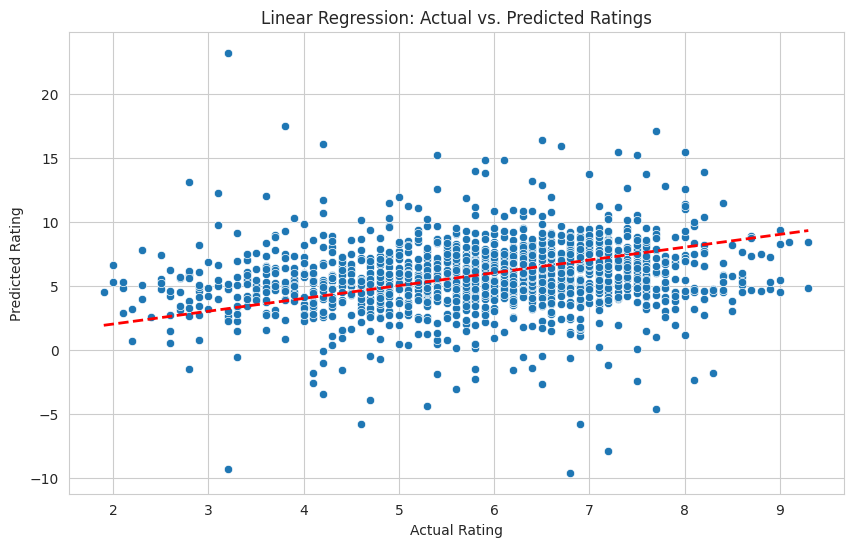

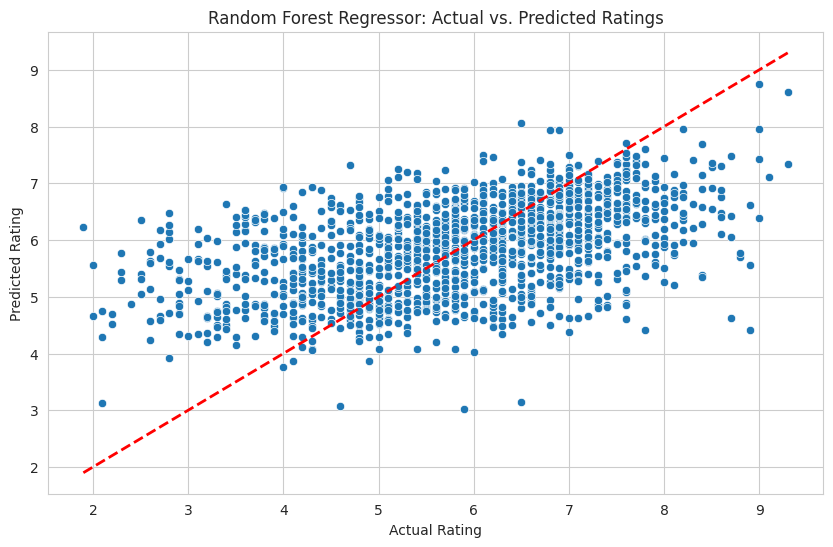

In [19]:
# Create a scatter plot for the Linear Regression model
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=lr_preds)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Linear Regression: Actual vs. Predicted Ratings')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.show()

# Create a scatter plot for the Random Forest model
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=rf_preds)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title('Random Forest Regressor: Actual vs. Predicted Ratings')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.show()

 # Model Performance Comparison
| Metric                             | Linear Regression | Random Forest Regressor |
| ---------------------------------- | ----------------- | ----------------------- |
| **Mean Absolute Error (MAE)**      | 1.91              | **0.91** (good)             |
| **Root Mean Squared Error (RMSE)** | 2.72              | **1.19** (good)              |


####Random Forest Regressor is clearly the better model based on both MAE and RMSE:

Lower MAE means that on average, the Random Forest model's predictions are closer to the true ratings than Linear Regression.

Lower RMSE indicates that the model makes fewer large errors, which is especially important in rating predictions where large deviations are more noticeable.



# Model Interpretability: Feature Importance

/tmp/ipython-input-21-2069735725.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='importance', y='feature', data=top_10_features, palette='viridis')


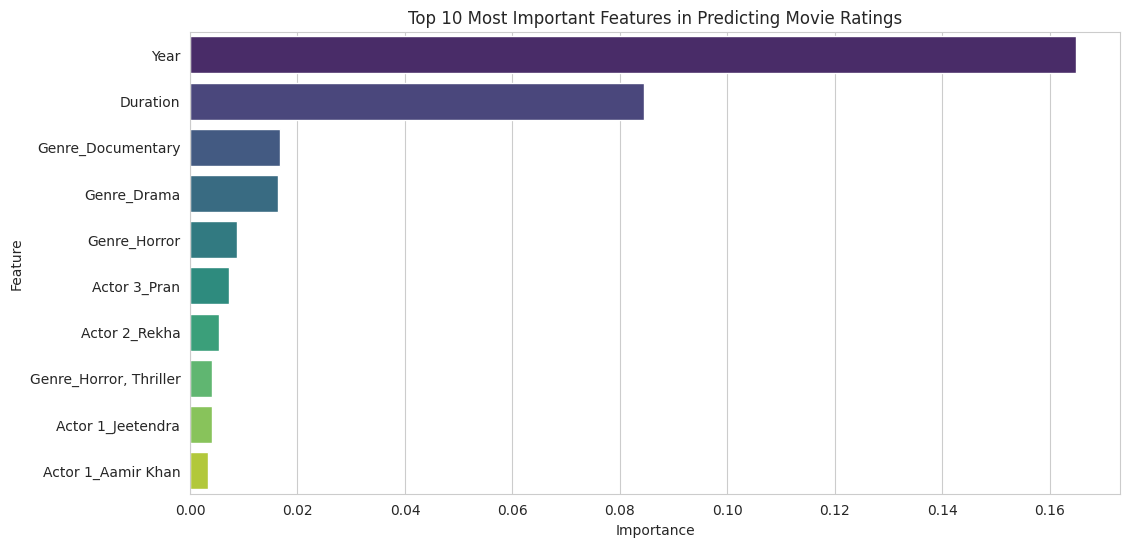

In [21]:
# Get feature importances from the Random Forest model
importances = rf_model.feature_importances_

# Create a dataframe of feature importances
feature_importances = pd.DataFrame({'feature': X.columns, 'importance': importances})
feature_importances = feature_importances.sort_values('importance', ascending=False)

# Get the top 10 most important features
top_10_features = feature_importances.head(10)

# Create a bar plot of the top 10 most important features
plt.figure(figsize=(12, 6))
sns.barplot(x='importance', y='feature', data=top_10_features, palette='viridis')
plt.title('Top 10 Most Important Features in Predicting Movie Ratings')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

### Model Interpretability: Feature Importance

After building a model, it's crucial to understand which features are most influential in its predictions. For our Random Forest Regressor, we can analyze the **feature importances**, which tell us how much each feature contributes to the model's predictive power.

The bar plot above shows the top 10 most important features in our model. Here are some key takeaways:

*   **Year and Duration are Key:** The 'Year' of release and the 'Duration' of the movie are by far the most important features. This suggests that when a movie was made and how long it is are strong indicators of its rating.
*   **Genre Matters:** As we saw in our EDA, 'Genre' is a significant factor. The model has learned that certain genres, like 'Documentary' and 'Horror', are particularly important in determining a movie's rating.
*   **Actors Have an Impact:** The model has also identified specific actors who are associated with higher or lower ratings, which is reflected in the importance of features like 'Actor 3_Pran' and 'Actor 2_Rekha'.

This analysis not only helps us understand our model better but also provides valuable insights into the factors that drive movie ratings in our dataset.

# Challenges Faced

*   **Data Quality and Missing Values:** The dataset had a significant number of missing values in several key columns, including 'Duration', 'Genre', 'Rating', and 'Votes'. This required a careful data cleaning and imputation strategy to avoid losing valuable data or introducing bias.

*   **Categorical Feature Explosion:** The 'Genre', 'Director', and 'Actor' columns had a very large number of unique values. One-hot encoding these features directly would lead to a massive number of new columns (the "curse of dimensionality"), which can make the model training process very slow and memory-intensive. We addressed this by grouping less frequent genres into an "Other" category, but a more sophisticated approach might be needed for a production-level system.

*   **Non-Linear Relationships:** The Linear Regression model performed poorly, indicating that the relationship between the features and the movie rating is not linear. This is a common challenge in real-world datasets, and it highlights the importance of trying more complex models like Random Forest that can capture these non-linear patterns.

*   **Feature Engineering for Text Data:** The 'Name' and 'Votes' columns were not used in our model, but they could potentially contain valuable information. Extracting useful features from text data (like the movie title) can be challenging and often requires more advanced natural language processing (NLP) techniques.

# Conclusion

This project aimed to predict movie ratings using a dataset of Indian films from IMDb. Through a structured machine learning workflow, we successfully developed and evaluated two regression models: Linear Regression and a Random Forest Regressor.

**Key Findings:**
*   **Exploratory Data Analysis (EDA)** revealed that movie ratings are influenced by factors such as genre, director, and lead actors. Notably, genres like 'Documentary' tended to have higher average ratings.
*   **Model Performance:** The Random Forest Regressor (RMSE: 1.19) significantly outperformed the Linear Regression model (RMSE: 2.72). This indicates that the relationships between the features and movie ratings are complex and non-linear, which the Random Forest algorithm is better equipped to handle.



In summary, this project successfully demonstrates the feasibility of predicting movie ratings and highlights the importance of choosing appropriate models that can capture the complexity of the data. The Random Forest model provides a solid baseline for future improvements.